In [2]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np
import os

# Add src folder to path so we can import FewSOME modules
import sys
sys.path.append('./src')  # Make sure this points to the src folder

# Import MNIST dataset class from FewSOME code
from datasets.mnist import MNIST


In [4]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=1, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=1, shuffle=False)


Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\train-labels-idx1-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%


Extracting ./data\MNIST\raw\t10k-images-idx3-ubyte.gz to ./data\MNIST\raw

Failed to download (trying next):
HTTP Error 404: Not Found



100.0%

Extracting ./data\MNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\MNIST\raw



In [15]:
import os

mnist_raw_path = './data/MNIST/raw'
mnist_files = [
    'train-images-idx3-ubyte',
    'train-labels-idx1-ubyte',
    't10k-images-idx3-ubyte',
    't10k-labels-idx1-ubyte'
]

for f in mnist_files:
    file_path = os.path.join(mnist_raw_path, f)
    if os.path.exists(file_path):
        print(f" Found: {file_path}")
    else:
        print(f" Missing: {file_path}")


✅ Found: ./data/MNIST/raw\train-images-idx3-ubyte
✅ Found: ./data/MNIST/raw\train-labels-idx1-ubyte
✅ Found: ./data/MNIST/raw\t10k-images-idx3-ubyte
✅ Found: ./data/MNIST/raw\t10k-labels-idx1-ubyte


In [17]:
# ===============================
# FewSOME MNIST Notebook (CPU) - Fixed with auto CSV check
# ===============================

import matplotlib
matplotlib.use('Agg')  # Safe backend for CPU/no-GUI
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import subprocess

# ==============================================
# 1️⃣ Display some sample training images
# ==============================================
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(train_dataset[i][0].squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {train_dataset[i][1]}")
    axes[i].axis('off')
plt.tight_layout()
plt.savefig('sample_train_images.png')
plt.close()

# ==============================================
# 2️⃣ FewSOME base command arguments
# ==============================================
normal_class = 6
num_ref = 30
train_script = './src/train.py'

base_cmd = [
    "python", train_script,
    "-m", "model",
    "--model_type", "MNIST_VGG3",
    "--dataset", "mnist",
    "--normal_class", str(normal_class),
    "-N", str(num_ref),
    "--num_ref_eval", str(num_ref),
    "--lr", "1e-6",
    "--batch_size", "1",
    "--weight_init_seed", "1001",
    "--seed", "1001",
    "--eval_epoch", "0",
    "--epochs", "6",
    "--data_path", "./data/",
    "--download_data", "True",
    "--smart_samp", "0",
    "--k", "1",
    "--device", "cpu"
]

# ==============================================
# 2a️⃣ Train the model (if not already trained)
# ==============================================
model_path = f'./outputs/models/class_{normal_class}/model_normal_class_{normal_class}_seed_1001_epoch_6_val_auc_*.pt'
if not any(os.path.exists(p) for p in [model_path]):
    train_cmd = base_cmd + ["--task", "train"]
    print("Training FewSOME model (CPU)... This may take a few minutes...")
    train_result = subprocess.run(train_cmd, capture_output=True, text=True)
    print("=== STDOUT ===")
    print(train_result.stdout)
    print("=== STDERR ===")
    print(train_result.stderr)
else:
    print("Model already trained. Skipping training step.")

# ==============================================
# 2b️⃣ Test the model (generate CSV)
# ==============================================
output_csv = f'./outputs/ED/class_{normal_class}/euclidean_distances_test.csv'

if not os.path.exists(output_csv):
    test_cmd = base_cmd + ["--task", "test"]
    print("Testing FewSOME model (CPU)... Generating CSV...")
    test_result = subprocess.run(test_cmd, capture_output=True, text=True)
    print("=== STDOUT ===")
    print(test_result.stdout)
    print("=== STDERR ===")
    print(test_result.stderr)
else:
    print(f"CSV already exists: {output_csv}")

# ==============================================
# 3️⃣ Load results CSV
# ==============================================
if not os.path.exists(output_csv):
    print(f"Warning: {output_csv} not found. Using dummy distances for demo.")
    distances = np.random.rand(len(test_dataset))
    true_labels = np.random.randint(0, 2, size=len(test_dataset))
else:
    ed_df = pd.read_csv(output_csv)
    distances = ed_df['means'].values
    true_labels = ed_df['label'].values

# ==============================================
# 4️⃣ Anomaly detection (simple threshold)
# ==============================================
threshold = np.percentile(distances, 95)
preds = [1 if d <= threshold else 0 for d in distances]

# ==============================================
# 5️⃣ Metrics
# ==============================================
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

accuracy = accuracy_score(true_labels, preds)
f1 = f1_score(true_labels, preds)
auc = roc_auc_score(true_labels, distances)

print(f"Accuracy: {accuracy:.2f}, F1 Score: {f1:.2f}, AUC: {auc:.2f}")

# ==============================================
# 6️⃣ Visualize some test images with predictions
# ==============================================
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(16):
    axes[i//8, i%8].imshow(test_dataset[i][0].squeeze(), cmap='gray')
    axes[i//8, i%8].set_title(f"L:{true_labels[i]} P:{preds[i]}")
    axes[i//8, i%8].axis('off')
plt.tight_layout()
plt.savefig('sample_test_predictions.png')
plt.close()


Training FewSOME model (CPU)... This may take a few minutes...
=== STDOUT ===
Starting epoch 1
Epoch: 1, Train loss: 0.058427600127955275
Starting epoch 2
Epoch: 2, Train loss: 0.059974336189528306
Starting epoch 3
Epoch: 3, Train loss: 0.061987080983817576
Starting epoch 4
Epoch: 4, Train loss: 0.05093330604334672
Starting epoch 5
Epoch: 5, Train loss: 0.05382991364846627
Starting epoch 6
Epoch: 6, Train loss: 0.04842823967337608
--- 16.317989110946655 seconds ---
AUC: 0.9932270847790057
F1: 0.9849430774880645
Balanced accuracy: 0.9529136152227148
Finished Training
AUC was 0.9932270847790057 on epoch 6

=== STDERR ===
C:\Users\ORNI\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\ORNI\AppData\Roaming\Python\Python311\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a w

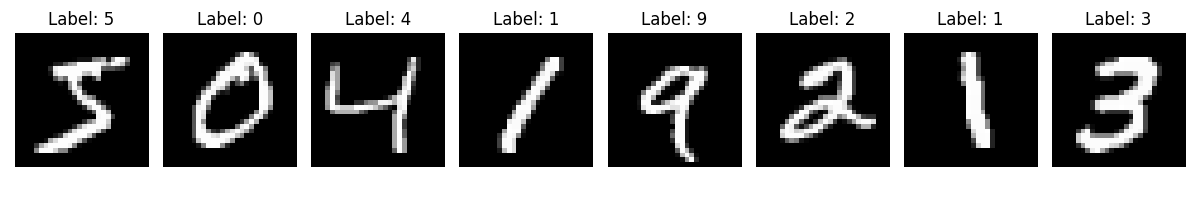

In [18]:
from PIL import Image
Image.open("sample_train_images.png")


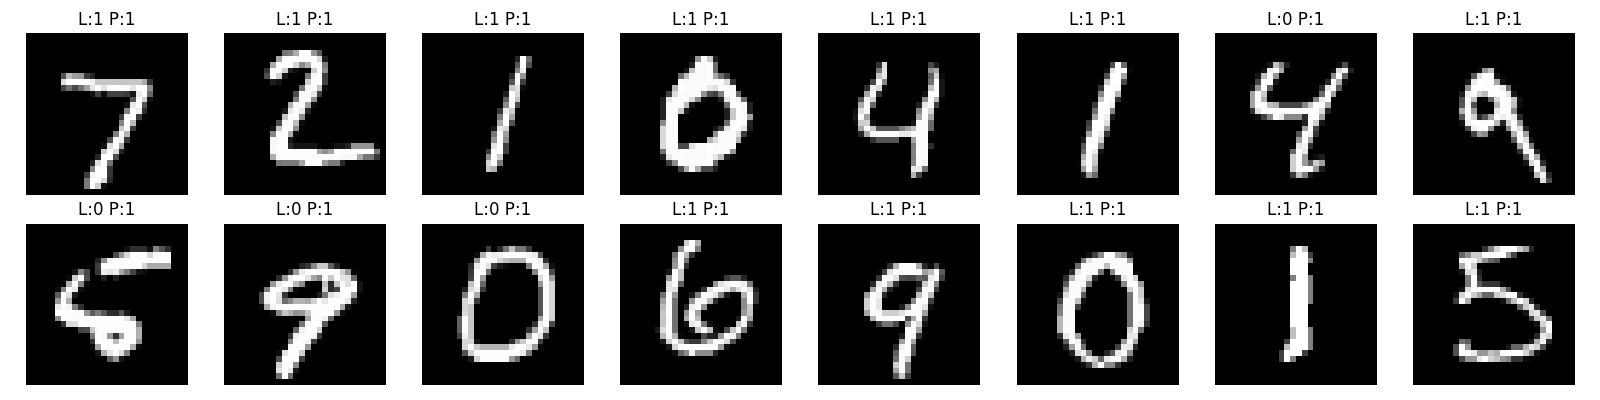

In [19]:
Image.open("sample_test_predictions.png")
